In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_adaptive_gaussian_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 19:57:44,755 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 19:57:44,760 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 19:57:44,774 - matplotlib - DEBUG - interactive is False
2026-05-10 19:57:44,774 - matplotlib - DEBUG - platform is linux
2026-05-10 19:57:44,830 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 19:57:44,831 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.ADAPTIVE_GAUSSIAN
CURRENT_DATASET = config.PNEUMONIAMNIST
CURRENT_RESOLUTION = 1 
specialist_name = ["Adaptive Gaussian"]

In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_adaptive_gaussian_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_val  = Y_val.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=1)

[I 2026-03-16 20:11:49,033] A new study created in memory with name: no-name-5ba85099-2aea-4945-8520-bc73779e8889


[I 2026-03-16 21:04:45,877] Trial 0 finished with value: 0.9412376495059802 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.9412376495059802.


[I 2026-03-16 21:55:49,050] Trial 1 finished with value: 0.9534883720930233 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 1 with value: 0.9534883720930233.


/home/coder/masters_thesis/.venv/lib/python3.12/site-packages/tmu/clause_bank/clause_bank_cuda.py:112: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = load_cuda_kernel(parameters, "cuda/calculate_clause_outputs_predict.cu")


/home/coder/masters_thesis/.venv/lib/python3.12/site-packages/tmu/clause_bank/clause_bank_cuda.py:118: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = load_cuda_kernel(parameters, "cuda/calculate_clause_outputs_update.cu")


...

[I 2026-03-18 19:23:19,913] Trial 46 finished with value: 0.9417273673257024 and parameters: {'s': 7.0, 'T': 7500, 'patch_size': 3, 'max_included_literals': 128}. Best is trial 14 with value: 0.9778692743180648.


[I 2026-03-18 20:32:42,010] Trial 47 finished with value: 0.9742268041237113 and parameters: {'s': 14.0, 'T': 5000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 14 with value: 0.9778692743180648.


[I 2026-03-18 21:40:02,059] Trial 48 finished with value: 0.9690721649484536 and parameters: {'s': 6.0, 'T': 6500, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 14 with value: 0.9778692743180648.


[I 2026-03-18 22:47:32,051] Trial 49 finished with value: 0.9679917398038204 and parameters: {'s': 10.0, 'T': 6500, 'patch_size': 5, 'max_included_literals': 512}. Best is trial 14 with value: 0.9778692743180648.


Best fbeta: 0.9778692743180648
Best hyperparameters: {'s': 9.0, 'T': 1000, 'patch_size': 9, 'max_included_literals': 128}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/adaptive_gaussian.json")

Best F1 score macro accuracy: 0.9778692743180648
Best hyperparameters: {'s': 9.0, 'T': 1000, 'patch_size': 9, 'max_included_literals': 128}
Best Optuna results saved to hyperparameters/adaptive_gaussian.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_gaussian.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="PneumoniaMNIST_Adaptive_Gaussian",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 88.62% (101.28s)


#2 Accuracy: 87.34% (92.40s)


#3 Accuracy: 87.34% (91.42s)


#4 Accuracy: 88.62% (89.34s)


...

#96 Accuracy: 87.66% (85.87s)


#97 Accuracy: 87.18% (85.89s)


#98 Accuracy: 87.98% (85.92s)


#99 Accuracy: 87.34% (85.72s)


#100 Accuracy: 88.14% (85.90s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "PneumoniaMNIST_Adaptive_Gaussian_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

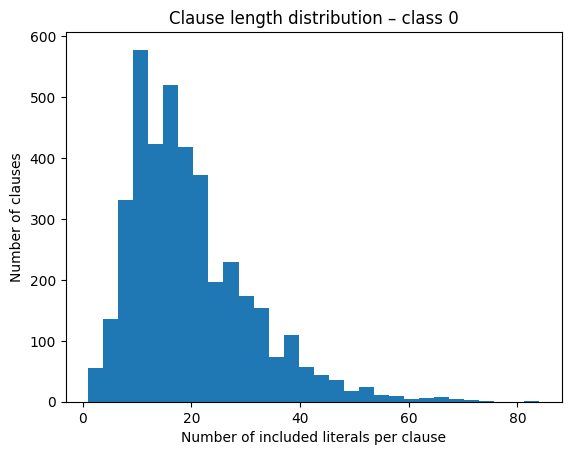

Class 0: median=17.0, mean=19.8, std=11.0


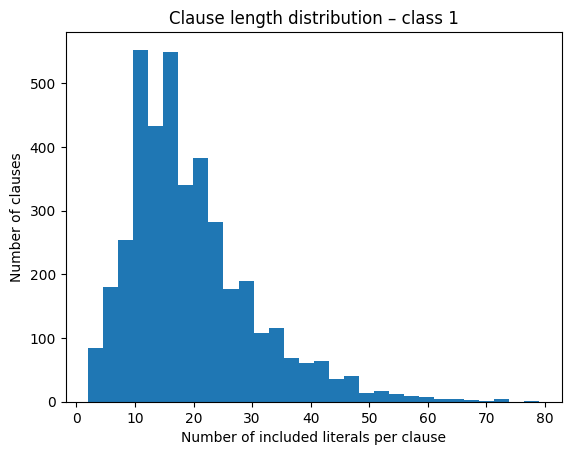

Class 1: median=17.0, mean=19.6, std=10.8


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 88.14%
2026-05-10 20:06:40,406 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x74d88aebdb50>


Saved to saved_confusion_matrices/pneumonia_adaptive_gaussian.svg


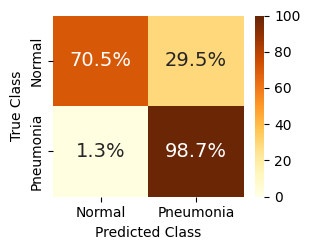

In [20]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="PneumoniaMNIST_Adaptive_Gaussian", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "YlOrBr") 

# Class 0 Local Examples 

In [ ]:
for i in range(3):
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 572
True class: 0
Predicted class: 0
Selected image index: 469
True class: 0
Predicted class: 0
Selected image index: 139
True class: 0
Predicted class: 0


0
2026-04-10 15:23:54,498 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:23:54,503 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 572  |  predicted class: 0
2026-04-10 15:23:54,537 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f440eab2fc0>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c0_s572_aggr.svg


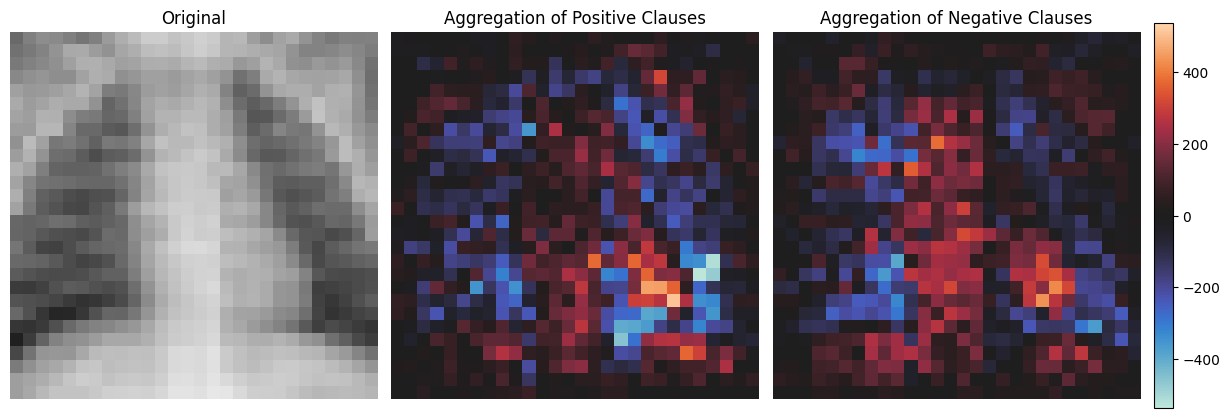

Visualizing sample 572  |  predicted class: 0
2026-04-10 15:23:58,197 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f44054fddf0>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c0_s572_chan.svg


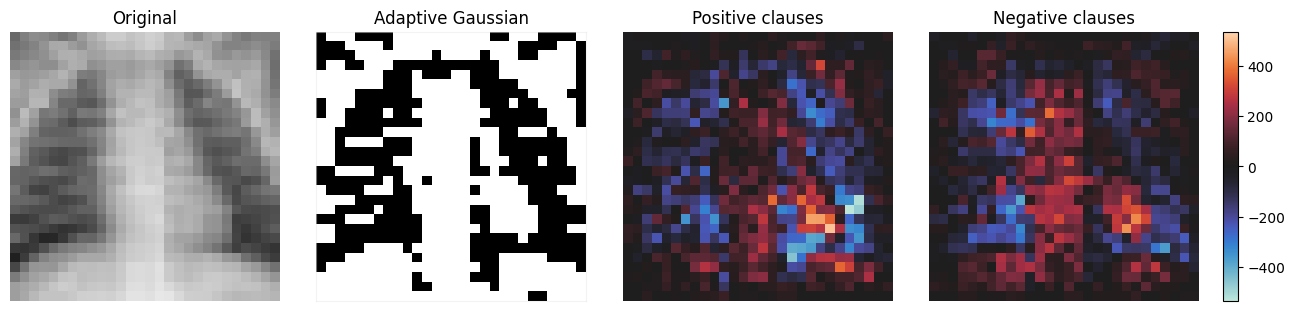

In [9]:
image_index =  572
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0


Visualizing sample 469  |  predicted class: 0
2026-04-10 15:24:01,978 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f440924c980>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c0_s469_aggr.svg


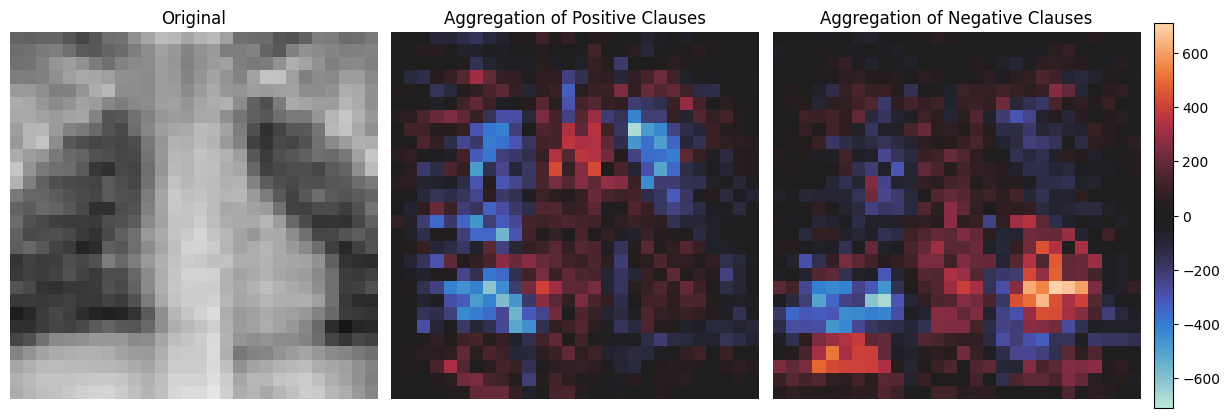

Visualizing sample 469  |  predicted class: 0
2026-04-10 15:24:05,605 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f4405468b00>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c0_s469_chan.svg


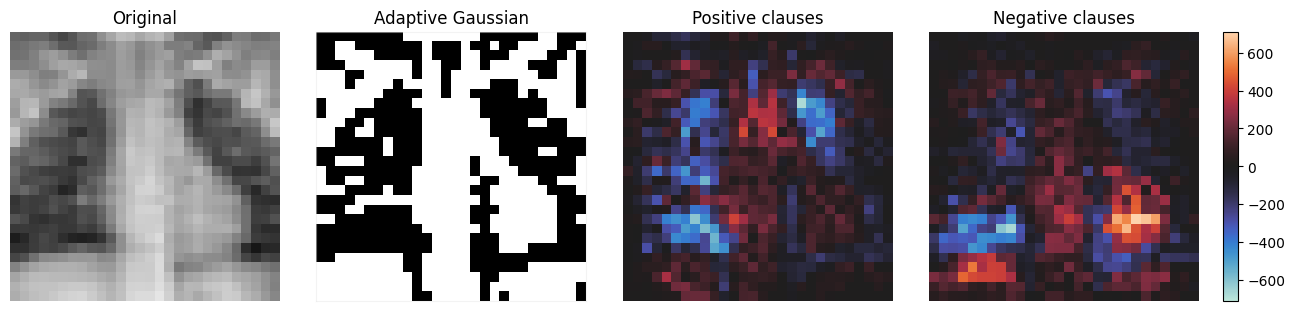

In [10]:
image_index =  469
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 139  |  predicted class: 0
2026-04-10 15:24:09,098 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f440537fda0>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c0_s139_aggr.svg


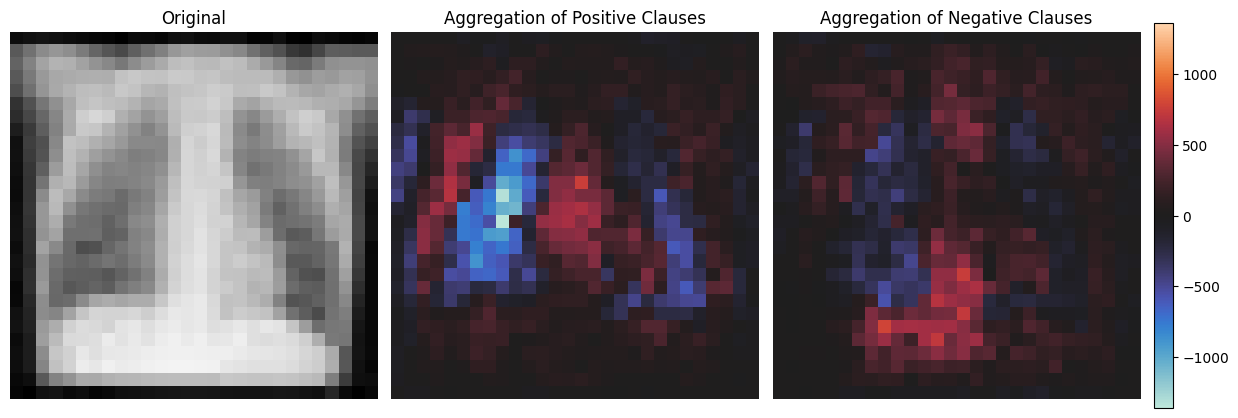

Visualizing sample 139  |  predicted class: 0
2026-04-10 15:24:12,621 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f440549a330>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c0_s139_chan.svg


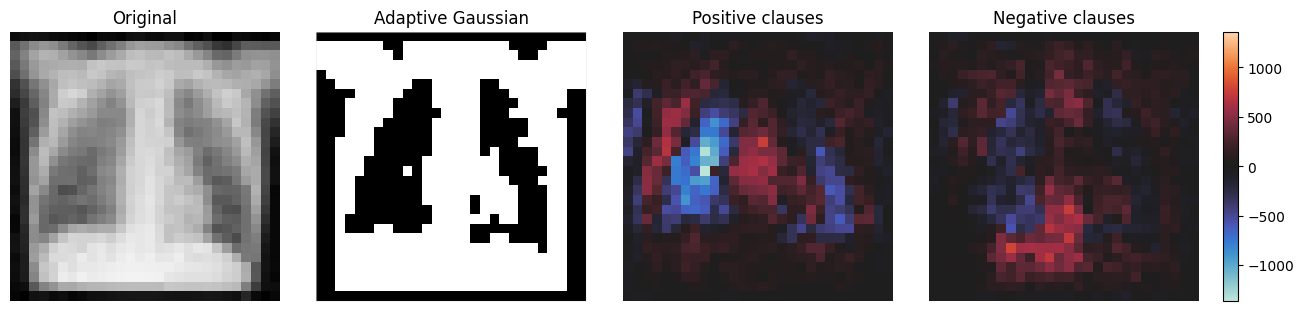

In [11]:
image_index =  139
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Class 1 Local Examples 

In [21]:
for i in range(3):
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 594
True class: 1
Predicted class: 1
Selected image index: 16
True class: 1
Predicted class: 1
Selected image index: 242
True class: 1
Predicted class: 1


1


Visualizing sample 594  |  predicted class: 1
2026-04-10 15:24:15,922 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f4400701ee0>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c1_s594_aggr.svg


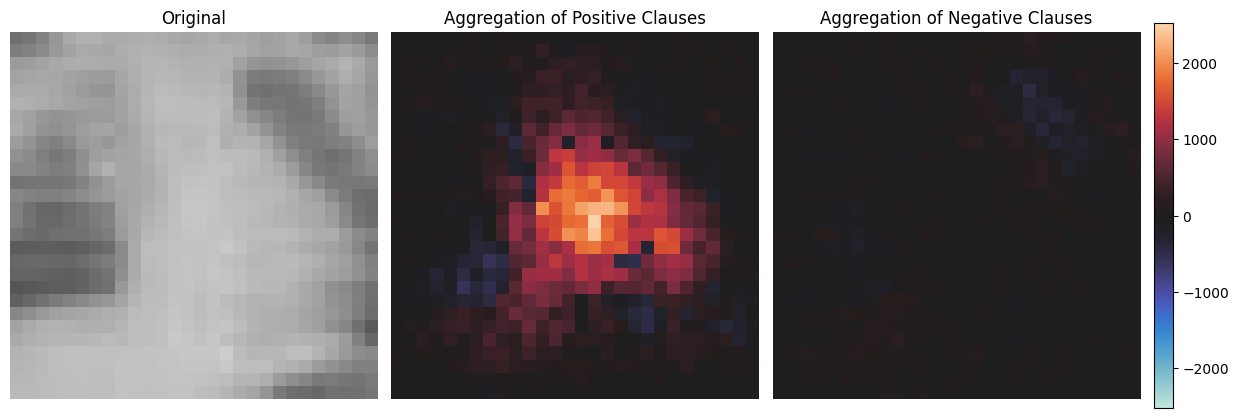

Visualizing sample 594  |  predicted class: 1
2026-04-10 15:24:19,088 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f4400693230>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c1_s594_chan.svg


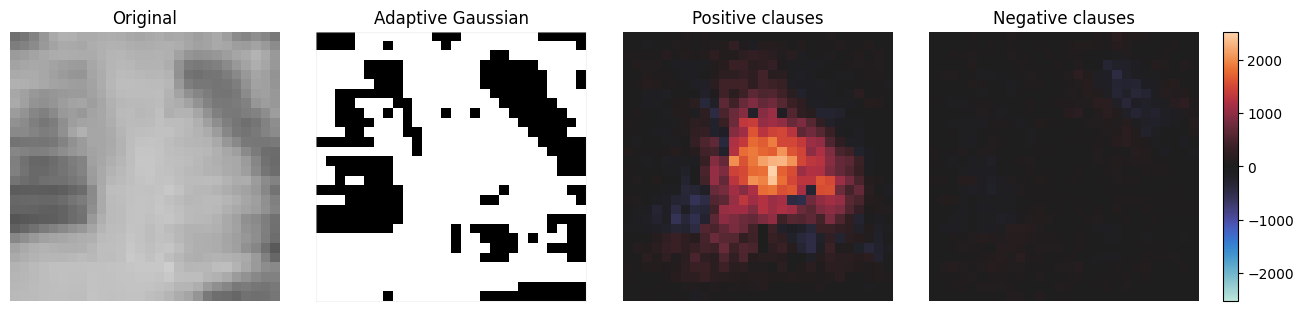

In [12]:
image_index =  594
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 563  |  predicted class: 1
2026-04-10 15:24:22,259 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f44004051c0>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c1_s563_aggr.svg


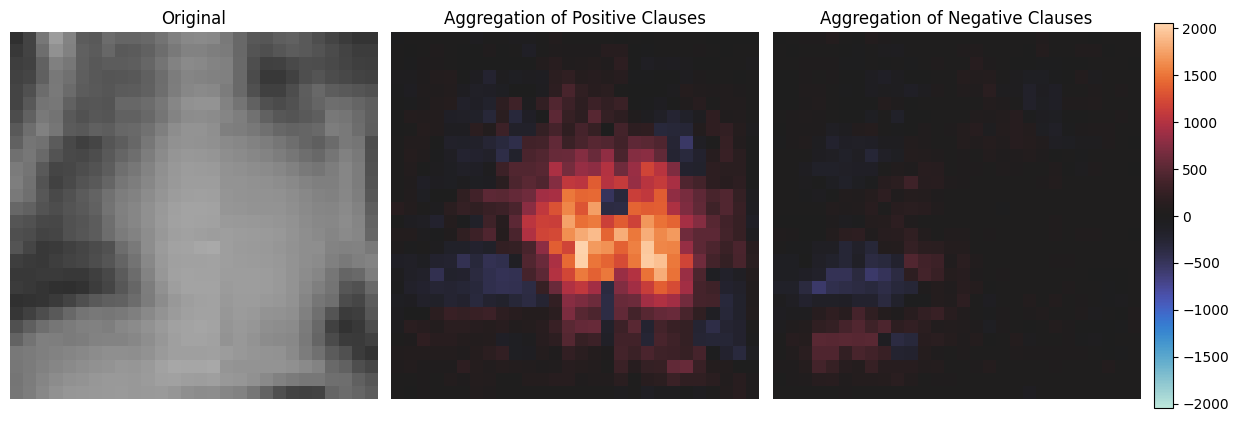

Visualizing sample 563  |  predicted class: 1
2026-04-10 15:24:25,592 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f4400469370>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c1_s563_chan.svg


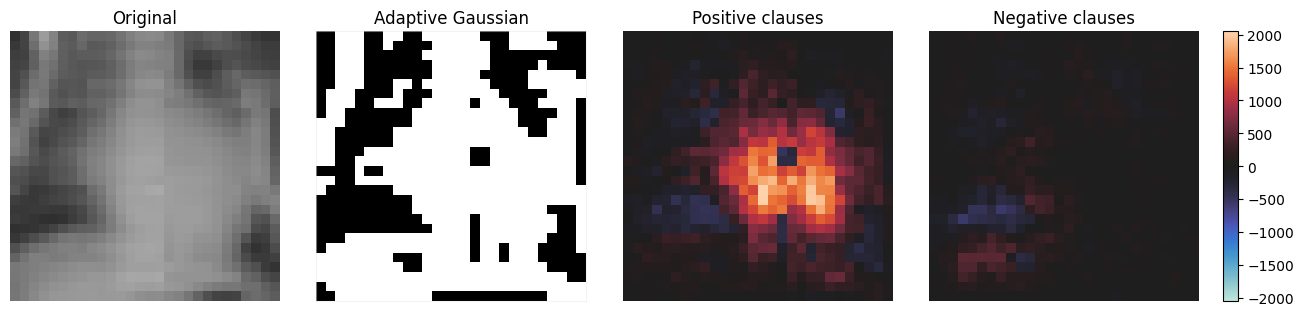

In [13]:
image_index =  563
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 242  |  predicted class: 1
2026-04-10 15:24:28,721 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f440051d2e0>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c1_s242_aggr.svg


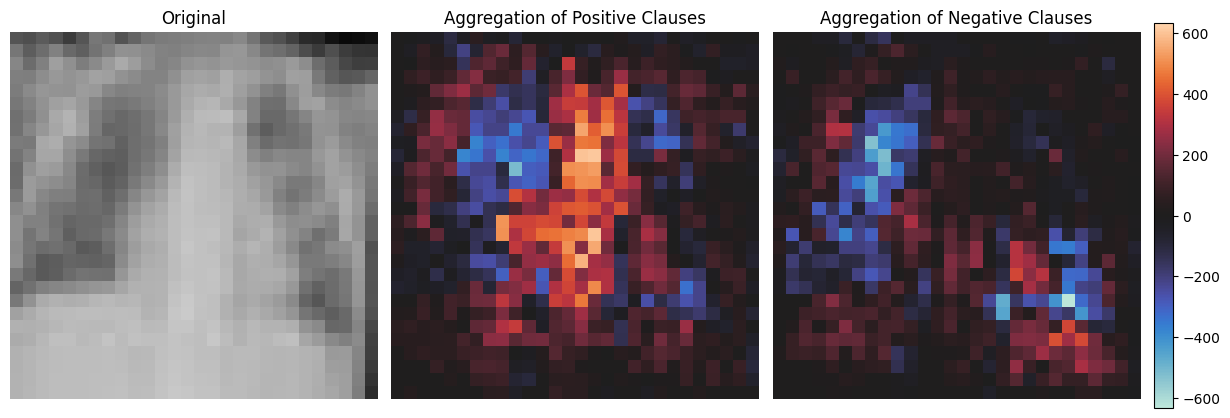

Visualizing sample 242  |  predicted class: 1
2026-04-10 15:24:32,270 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f4400788c80>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_lh_c1_s242_chan.svg


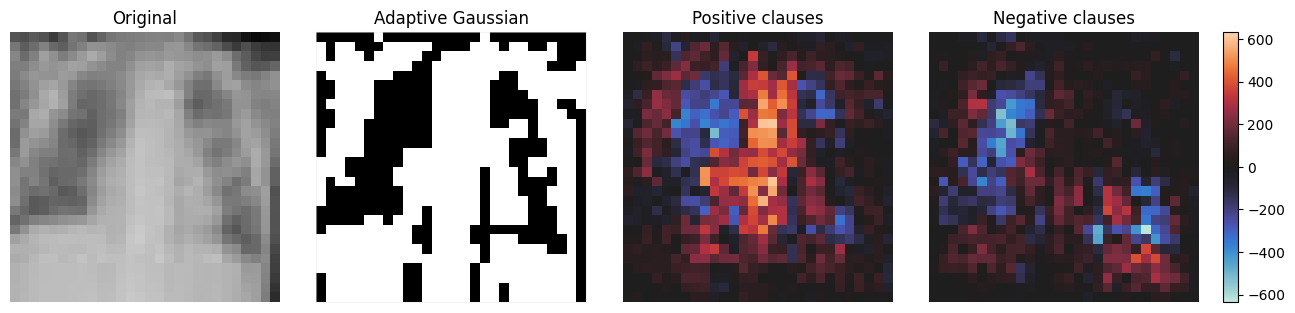

In [14]:
image_index =  242
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Global Heatmap 0

Averaging over 165 correctly predicted samples of class 0
  processed 100/165
2026-04-06 16:25:54,795 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79008ef1cf50>


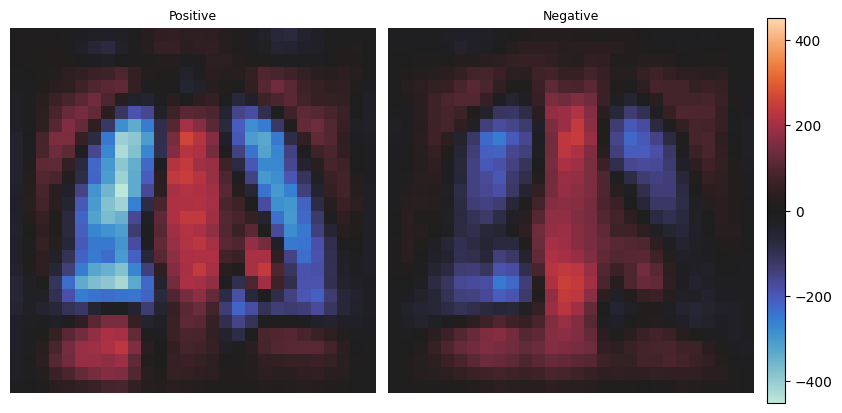

In [14]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 0

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:13:21,646 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:13:21,649 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:13:21,674 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x710b63146c30>
Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_gh_c0.svg


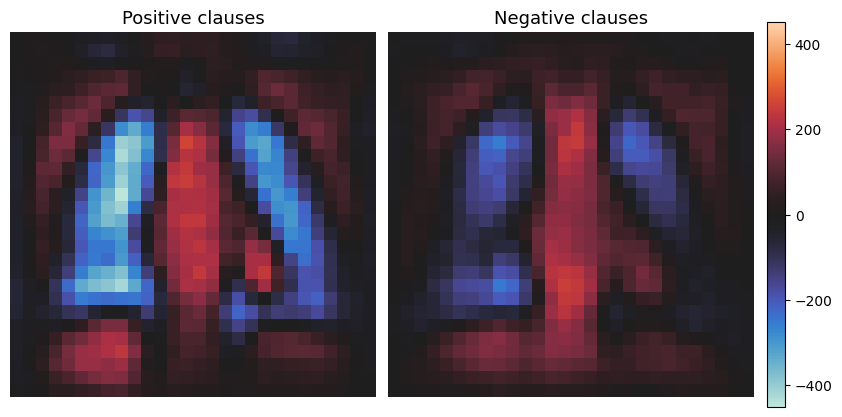

pos shape: (28, 28), min: -451.31, max: 263.43
neg shape: (28, 28), min: -255.72, max: 253.29
saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_gh_c0.svg


In [6]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

In [11]:
target_class = 1

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)

np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

KeyboardInterrupt: 

2026-04-10 19:13:25,316 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x710b5a079550>


Saved to saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_gh_c1.svg


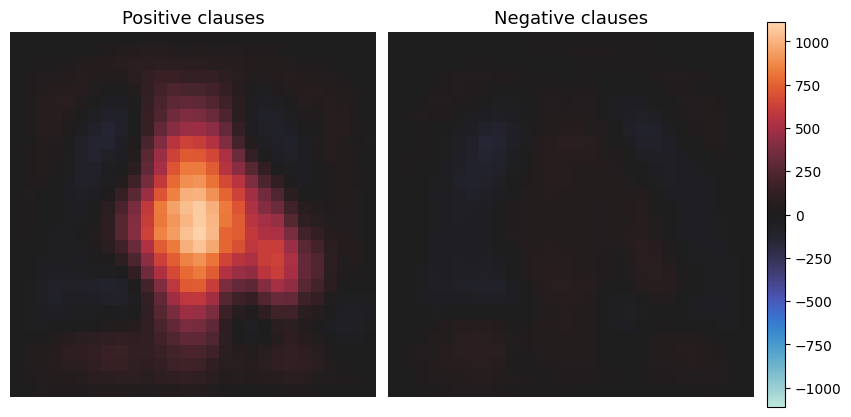

pos shape: (28, 28), min: -130.39, max: 1112.31
neg shape: (28, 28), min: -142.01, max: 88.70
saved_heatmaps/adaptive_gaussian/pneumonia_adaptive_gaussian_gh_c1.svg


In [7]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)